In [1]:
import os
import librosa
from librosa import display
import numpy as np
import IPython.display as ipd
import matplotlib as plt
import soundfile as sf
import sounddevice as sd
from scipy.signal import butter, filtfilt
import pyloudnorm as pyln
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim.adam as adam
import tensorflow as tf
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
import itertools

In [5]:
power = 3

def wake_word(y,sr):
    S_full, phase = librosa.magphase(librosa.stft(y))
    idx = slice(*librosa.time_to_frames([90*110], sr=sr))
    S_filter = librosa.decompose.nn_filter(S_full, aggregate=np.median, metric='cosine', width=15)
    S_filter = np.minimum(S_full, S_filter)
    margin_v = 11
    mask1 = librosa.util.softmask(S_full - S_filter, margin_v * S_filter, power=power)
    S_hi = mask1 * S_full
    y1 = librosa.istft(S_hi * phase)
    return y1
    

def record_background(y,sr):
    S_full, phase = librosa.magphase(librosa.stft(y))
    idx = slice(*librosa.time_to_frames([90*110], sr=sr))
    S_filter = librosa.decompose.nn_filter(S_full, aggregate=np.median, metric='cosine', width=15)
    S_filter = np.minimum(S_full, S_filter)
    margin_i = 3
    mask2 = librosa.util.softmask(S_filter, margin_i * (S_full - S_filter), power=power)
    S_back = mask2 * S_full
    y2 = librosa.istft(S_back * phase)
    return y2 

def adding_noise(audio1):
    noise_level=0.1
    noise = np.random.normal(0, noise_level, len(audio1))
    noisy_audio = audio1 + noise
    return noisy_audio

def shifting(audio2,sample_rate1):
    max_shift=0.2
    shift_samples = int(np.random.uniform(-max_shift * sample_rate1, max_shift * sample_rate1))
    shifted_waveform = np.roll(audio2, shift_samples)
    return shifted_waveform

def speed_pitch(audio3, sample_rate2):
    pitch_shift=2
    speed_factor=1.2
    y_pitch_speed = librosa.effects.pitch_shift(y=audio3, sr=sample_rate2, n_steps=2)
    y_pitch_speed = librosa.effects.time_stretch(y_pitch_speed, rate=speed_factor)
    return y_pitch_speed

In [6]:
def feature_extraction(y_voice_2 ,sr_voice_2):  
    max_len=100
    n_mfcc_2=13
    mfcc = librosa.feature.mfcc(y=y_voice_2, sr=sr_voice_2, n_mfcc=n_mfcc_2)
    
    mfcc = mfcc.T
    
    if mfcc.shape[0] > max_len:
        mfcc = mfcc[:max_len, :]
    else:
        pad_width = max_len - mfcc.shape[0]
        mfcc = np.pad(mfcc, pad_width=((0, pad_width), (0, 0)), mode='constant')
    return torch.Tensor(mfcc)

In [7]:
y_vocal = []
y_background = []
path = "C:/Users/SHAYAN/Desktop/extra/voices/en"
for audio_file in os.listdir(path):
        if audio_file.endswith('.wav'): 
            y1, sr1 = librosa.load(f"C:/Users/SHAYAN/Desktop/extra/voices/en/{audio_file}")
            y_back = record_background(y1 , sr1)
            y_voice = wake_word(y1 , sr1)
            
           
            # ............................................. augmentation...................................
            y_voice_shifted = shifting(y_voice,sr1)
            y_voice_noisy = adding_noise(y_voice)
            y_voice_speedchange = speed_pitch(y_voice,sr1)


            
            y_back_shifted = shifting(y_back,sr1)
            y_back_noisy = adding_noise(y_back)
            y_back_speedchange = speed_pitch(y_back, sr1)
            
            
            

            #.............................................remove silence....................................

            # background voice
            non_silent_intervals = librosa.effects.split(y_back, top_db=20)
            y_back = np.concatenate([y_back[start:end] for start, end in non_silent_intervals])
            
            non_silent_intervals = librosa.effects.split(y_back_shifted, top_db=20)
            y_back_shifted = np.concatenate([y_back_shifted[start:end] for start, end in non_silent_intervals])
            
            non_silent_intervals = librosa.effects.split(y_back_noisy, top_db=20)
            y_back_noisy = np.concatenate([y_back_noisy[start:end] for start, end in non_silent_intervals])

            non_silent_intervals = librosa.effects.split(y_back_speedchange, top_db=20)
            y_back_speedchange = np.concatenate([y_back_speedchange[start:end] for start, end in non_silent_intervals])

            # forground voice
            non_silent_intervals = librosa.effects.split(y_voice, top_db=20)
            y_voice = np.concatenate([y_voice[start:end] for start, end in non_silent_intervals])
            
            non_silent_intervals = librosa.effects.split(y_voice_shifted, top_db=20)
            y_voice_shifted = np.concatenate([y_voice_shifted[start:end] for start, end in non_silent_intervals])
            
            non_silent_intervals = librosa.effects.split(y_voice_noisy, top_db=20)
            y_voice_noisy = np.concatenate([y_voice_noisy[start:end] for start, end in non_silent_intervals])
            
            non_silent_intervals = librosa.effects.split(y_voice_speedchange, top_db=20)
            y_voice_speedchange = np.concatenate([y_voice_speedchange[start:end] for start, end in non_silent_intervals])
            
            #.......................................feature extraction......................................

            mfccs_voice1 =  feature_extraction(y_voice, sr1).flatten() 
            mfccs_voice2 =  feature_extraction(y_voice_shifted, sr1).flatten()
            mfccs_voice3 =  feature_extraction(y_voice_noisy, sr1).flatten() 
            mfccs_voice4 =  feature_extraction(y_voice_speedchange, sr1).flatten() 


            mfccs_back1 =  feature_extraction(y_back, sr1).flatten()  
            mfccs_back2 =  feature_extraction(y_back_shifted, sr1).flatten()
            mfccs_back3 =  feature_extraction(y_back_noisy, sr1).flatten()  
            mfccs_back4 =  feature_extraction(y_back_speedchange, sr1).flatten() 
            
            
            y_background.append(mfccs_back1)
            y_background.append(mfccs_back2)
            y_background.append(mfccs_back3)
            y_background.append(mfccs_back4)

            
            y_vocal.append(mfccs_voice1)
            y_vocal.append(mfccs_voice2)
            y_vocal.append(mfccs_voice3)
            y_vocal.append(mfccs_voice4)

In [8]:
label_0 = torch.Tensor([0]*len(y_vocal))
label_1 = torch.Tensor([1]*len(y_background))

In [11]:
labels = torch.cat((label_0, label_1), dim=0)
labels = labels.view(-1,1)

In [9]:
y_vocal = torch.stack(y_vocal)
y_background = torch.stack(y_background)

In [10]:
y = torch.cat((y_background,y_vocal), dim=0)

In [22]:
x, data_valid, y_total, labels_valid = train_test_split(y, labels, test_size=0.2)

print("Train+test set size:", len(x))
print("Validation set size:", len(data_valid))


data_train, data_test, labels_train, labels_test = train_test_split(x, y_total, test_size=0.25)

print("Training set size:", len(data_train))
print("test set size:", len(data_test))

Train+test set size: 1427
Validation set size: 357
Training set size: 1070
test set size: 357


In [23]:
train_dataset = TensorDataset(data_train, labels_train)
valid_dataset = TensorDataset(data_valid, labels_valid)
test_dataset = TensorDataset(data_test, labels_test)

In [24]:
batch_size = 8

train_dataloader = DataLoader(
            train_dataset,
            shuffle = True,
            batch_size = batch_size
        )
valid_dataloader = DataLoader(
            valid_dataset,
            shuffle = True,
            batch_size = batch_size
        )
test_dataloader = DataLoader(
            test_dataset,
            shuffle = True,
            batch_size = batch_size
        )

In [25]:
def plot_confusion_matrix(cm,classes,
                          normalize=False,
                          title='confusion matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('confusion matrix, without normalization')
    plt.imshow(cm,interpolation='nearest',cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i,j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j,i,format(cm[i,j],fmt),
                horizontalalignment="center",
                color="white" if cm[i,j] > thresh else "black")
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('predicted label')
    plt.show()

In [26]:
class voice(nn.Module):
    def __init__(self):
        super(voice, self).__init__()
        self.fc1 = nn.Linear(1300,1024)             
        self.fc2 = nn.Linear(1024,768)
        self.fc3 = nn.Linear(768,512)
        self.fc4 = nn.Linear(512,256)
        self.fc5 = nn.Linear(256,64)
        self.fc6 = nn.Linear(64,1)
        self.sig = nn.Sigmoid()
    def forward(self, y_input):           
        x = self.fc1(y_input)
        x = self.fc2(x)
        x = self.fc3(x)
        x = self.fc4(x)
        x = self.fc5(x)
        x = self.fc6(x)
        x = self.sig(x)

        return x

model = voice()
learning_rate = 2e-5
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

Epoch [1/4], train_accuracy: 0.8663551401869158, train_loss: 0.3108161885644059, valid_accuracy: 0.8851540616246498 , valid_loss: 0.21332636490050289 
Epoch [2/4], train_accuracy: 0.9392523364485982, train_loss: 0.14691546822701748, valid_accuracy: 0.927170868347339 , valid_loss: 0.16170732118189335 
Epoch [3/4], train_accuracy: 0.9682242990654205, train_loss: 0.10591849990913631, valid_accuracy: 0.9327731092436975 , valid_loss: 0.16023107300231157 
Epoch [4/4], train_accuracy: 0.9719626168224299, train_loss: 0.08088949016850328, valid_accuracy: 0.9355742296918768 , valid_loss: 0.13819551535642757 


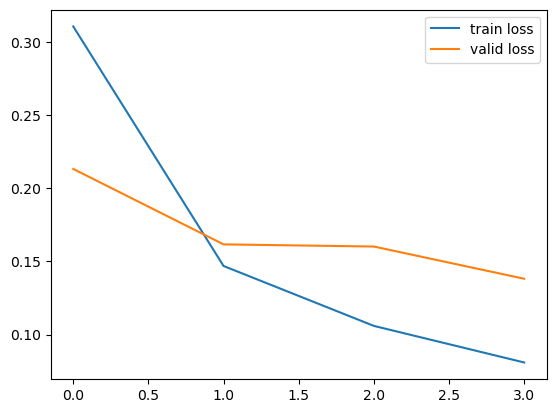

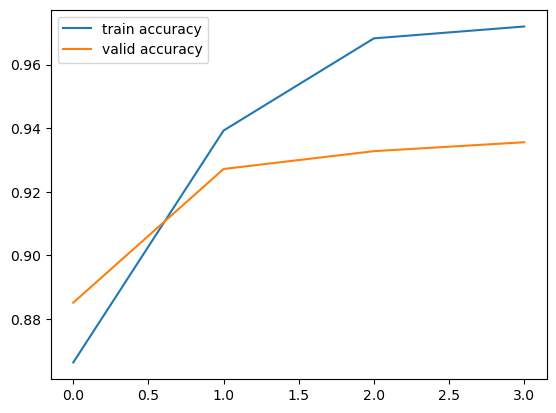

In [27]:
num_epochs = 4

train_losses = np.zeros(num_epochs)
valid_losses = np.zeros(num_epochs)
train_accuracy = np.zeros(num_epochs)
valid_accuracy = np.zeros(num_epochs)
for epoch in range(num_epochs):
    train_loss = []
    valid_loss = []
    n_correct1 = 0
    n_total1 = 0
    model.train()
    for step,batch in enumerate(train_dataloader):
        input = batch[0]
        targets = batch[1]
        outputs = model(input)
        #outputs = outputs.float
        loss = criterion(outputs,targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss.append(loss.item())
        predictions = outputs.round()
        n_correct1 += torch.sum(predictions == targets).item()
        n_total1 += targets.shape[0] 
        
    
    train_acc = n_correct1 / n_total1
    
    train_loss=np.mean(train_loss)
    train_losses[epoch] = train_loss
    train_accuracy[epoch] = train_acc
    model.eval()
    n_correct2 = 0
    n_total2 = 0
    for step,batch in enumerate(valid_dataloader):
        input = batch[0]
        targets = batch[1]
        outputs = model(input)
        loss = criterion(outputs, targets)
        valid_loss.append(loss.item())
        # Print training statistics
        predictions = outputs.round()
        n_correct2 += torch.sum(predictions == targets).item()
        n_total2 += targets.shape[0] 
          
    valid_acc = n_correct2 / n_total2 
    valid_loss=np.mean(valid_loss)
    valid_accuracy[epoch] = valid_acc
    valid_losses[epoch] = valid_loss
            
        
    
    print(f"Epoch [{epoch+1}/{num_epochs}], train_accuracy: {train_acc}, train_loss: {train_loss}, valid_accuracy: {valid_acc} , valid_loss: {valid_loss} ")
plt.plot(train_losses, label='train loss')
plt.plot(valid_losses, label='valid loss')
plt.legend()
plt.show()
plt.plot(train_accuracy, label='train accuracy')
plt.plot(valid_accuracy, label='valid accuracy')
plt.legend()
plt.show()

confusion matrix, without normalization


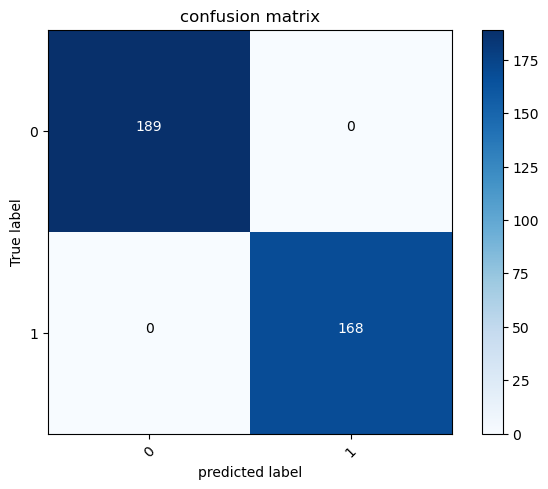

test_accuracy: 0.9467787114845938, test_loss: 0.11172570566226972


In [46]:
test_loss = []
n_correct = 0
n_total = 0
y_true = []
y_pred = []
labels_test1 = np.array([])
p_test = np.array([])
with torch.no_grad():
    for step,batch in enumerate(test_dataloader):
        input = batch[0]
        targets = batch[1]
        outputs = model(input)
        loss = criterion(outputs,targets)
        # Perform backwar1d pass and optimization
        test_loss.append(loss.item())
        predictions = outputs.round()
        n_correct += torch.sum(predictions == targets).item()
        n_total += targets.shape[0] 
        y_true.append(targets.flatten())
        y_pred.append(outputs.round())
        labels_test1 = np.concatenate((labels_test1, predictions.numpy().reshape(-1)))
        p_test = np.concatenate((p_test, predictions.numpy().reshape(-1))) 


y_pred = torch.cat(y_pred, dim=0)
y_pred = np.array(y_pred)
cm = confusion_matrix(np.array(labels_test1),p_test)
test_acc = n_correct / n_total
test_loss=np.mean(test_loss)
plot_confusion_matrix(cm,list(range(2)))
print(f"test_accuracy: {test_acc}, test_loss: {test_loss}")